# 1. Data Preparation:

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate,  cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time
from time import time
from sklearn.metrics import roc_auc_score, make_scorer
from matplotlib.pylab import rcParams
from sklearn.tree import plot_tree
import graphviz
import warnings
warnings.filterwarnings("ignore")

In [43]:
dataset = pd.read_excel(r"C:\Users\sangm\Documents\heart_disease.xlsx",sheet_name="Heart_disease")
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


# 2. Exploratory Data Analysis (EDA):

In [44]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [45]:
dataset.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [46]:
dataset.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [47]:
dataset['sex'].value_counts()

sex
Male      718
Female    190
Name: count, dtype: int64

In [48]:
dataset['oldpeak'] = dataset['oldpeak'].fillna(dataset['oldpeak'].mean())

In [49]:
dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [50]:
dataset.shape

(908, 13)

# 3. Feature Engineering:

In [51]:
dataset=dataset.replace({True: 1, False: 0})
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,1,lv hypertrophy,150,0,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,0,normal,132,0,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,0,normal,148,0,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,0,lv hypertrophy,190,0,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,0,normal,126,1,1.5,flat,fixed defect,0


In [52]:
u1=dataset['sex'].unique()
u2=dataset['cp'].unique()
u3=dataset['fbs'].unique()
u4=dataset['restecg'].unique()
u5=dataset['exang'].unique()
u6=dataset['slope'].unique()
u7=dataset['thal'].unique()
print (u1)
print (u2)
print (u3)
print (u4)
print (u5)
print (u6)
print (u7)

['Male' 'Female']
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
[1 0]
['lv hypertrophy' 'normal' 'st-t abnormality']
[0 1 'FALSE' 'TURE']
['downsloping' 'flat' 'upsloping']
['fixed defect' 'normal' 'reversable defect']


## Define the mapping dictionary

In [53]:
dataset['sex'] = dataset['sex'].map({'Male':1,'Female':2})
dataset['cp'] = dataset['cp'].map({'typical angina':1,'atypical angina':2,'asymptomatic':3,'non-anginal':4})
dataset['restecg'] = dataset['restecg'].map({'lv hypertrophy':1,'normal':2,'st-t abnormality':3})
dataset['exang'] = dataset['exang'].map({'TRUE':1,'FALSE':0,'TURE':1})
dataset['slope'] = dataset['slope'].map({'downsloping':1,'flat':2,'upsloping':3})
dataset['thal'] = dataset['thal'].map({'fixed defect':1,'normal':2,'reversable defect':3})
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,1,145,233,1,1,150,NaN,2.3,1,1,0
1,41,1,2,135,203,0,2,132,NaN,0.0,2,1,0
2,57,1,3,140,192,0,2,148,NaN,0.4,2,1,0
3,52,1,1,118,186,0,1,190,NaN,0.0,2,1,0
4,57,1,3,110,201,0,2,126,NaN,1.5,2,1,0


# Visualization

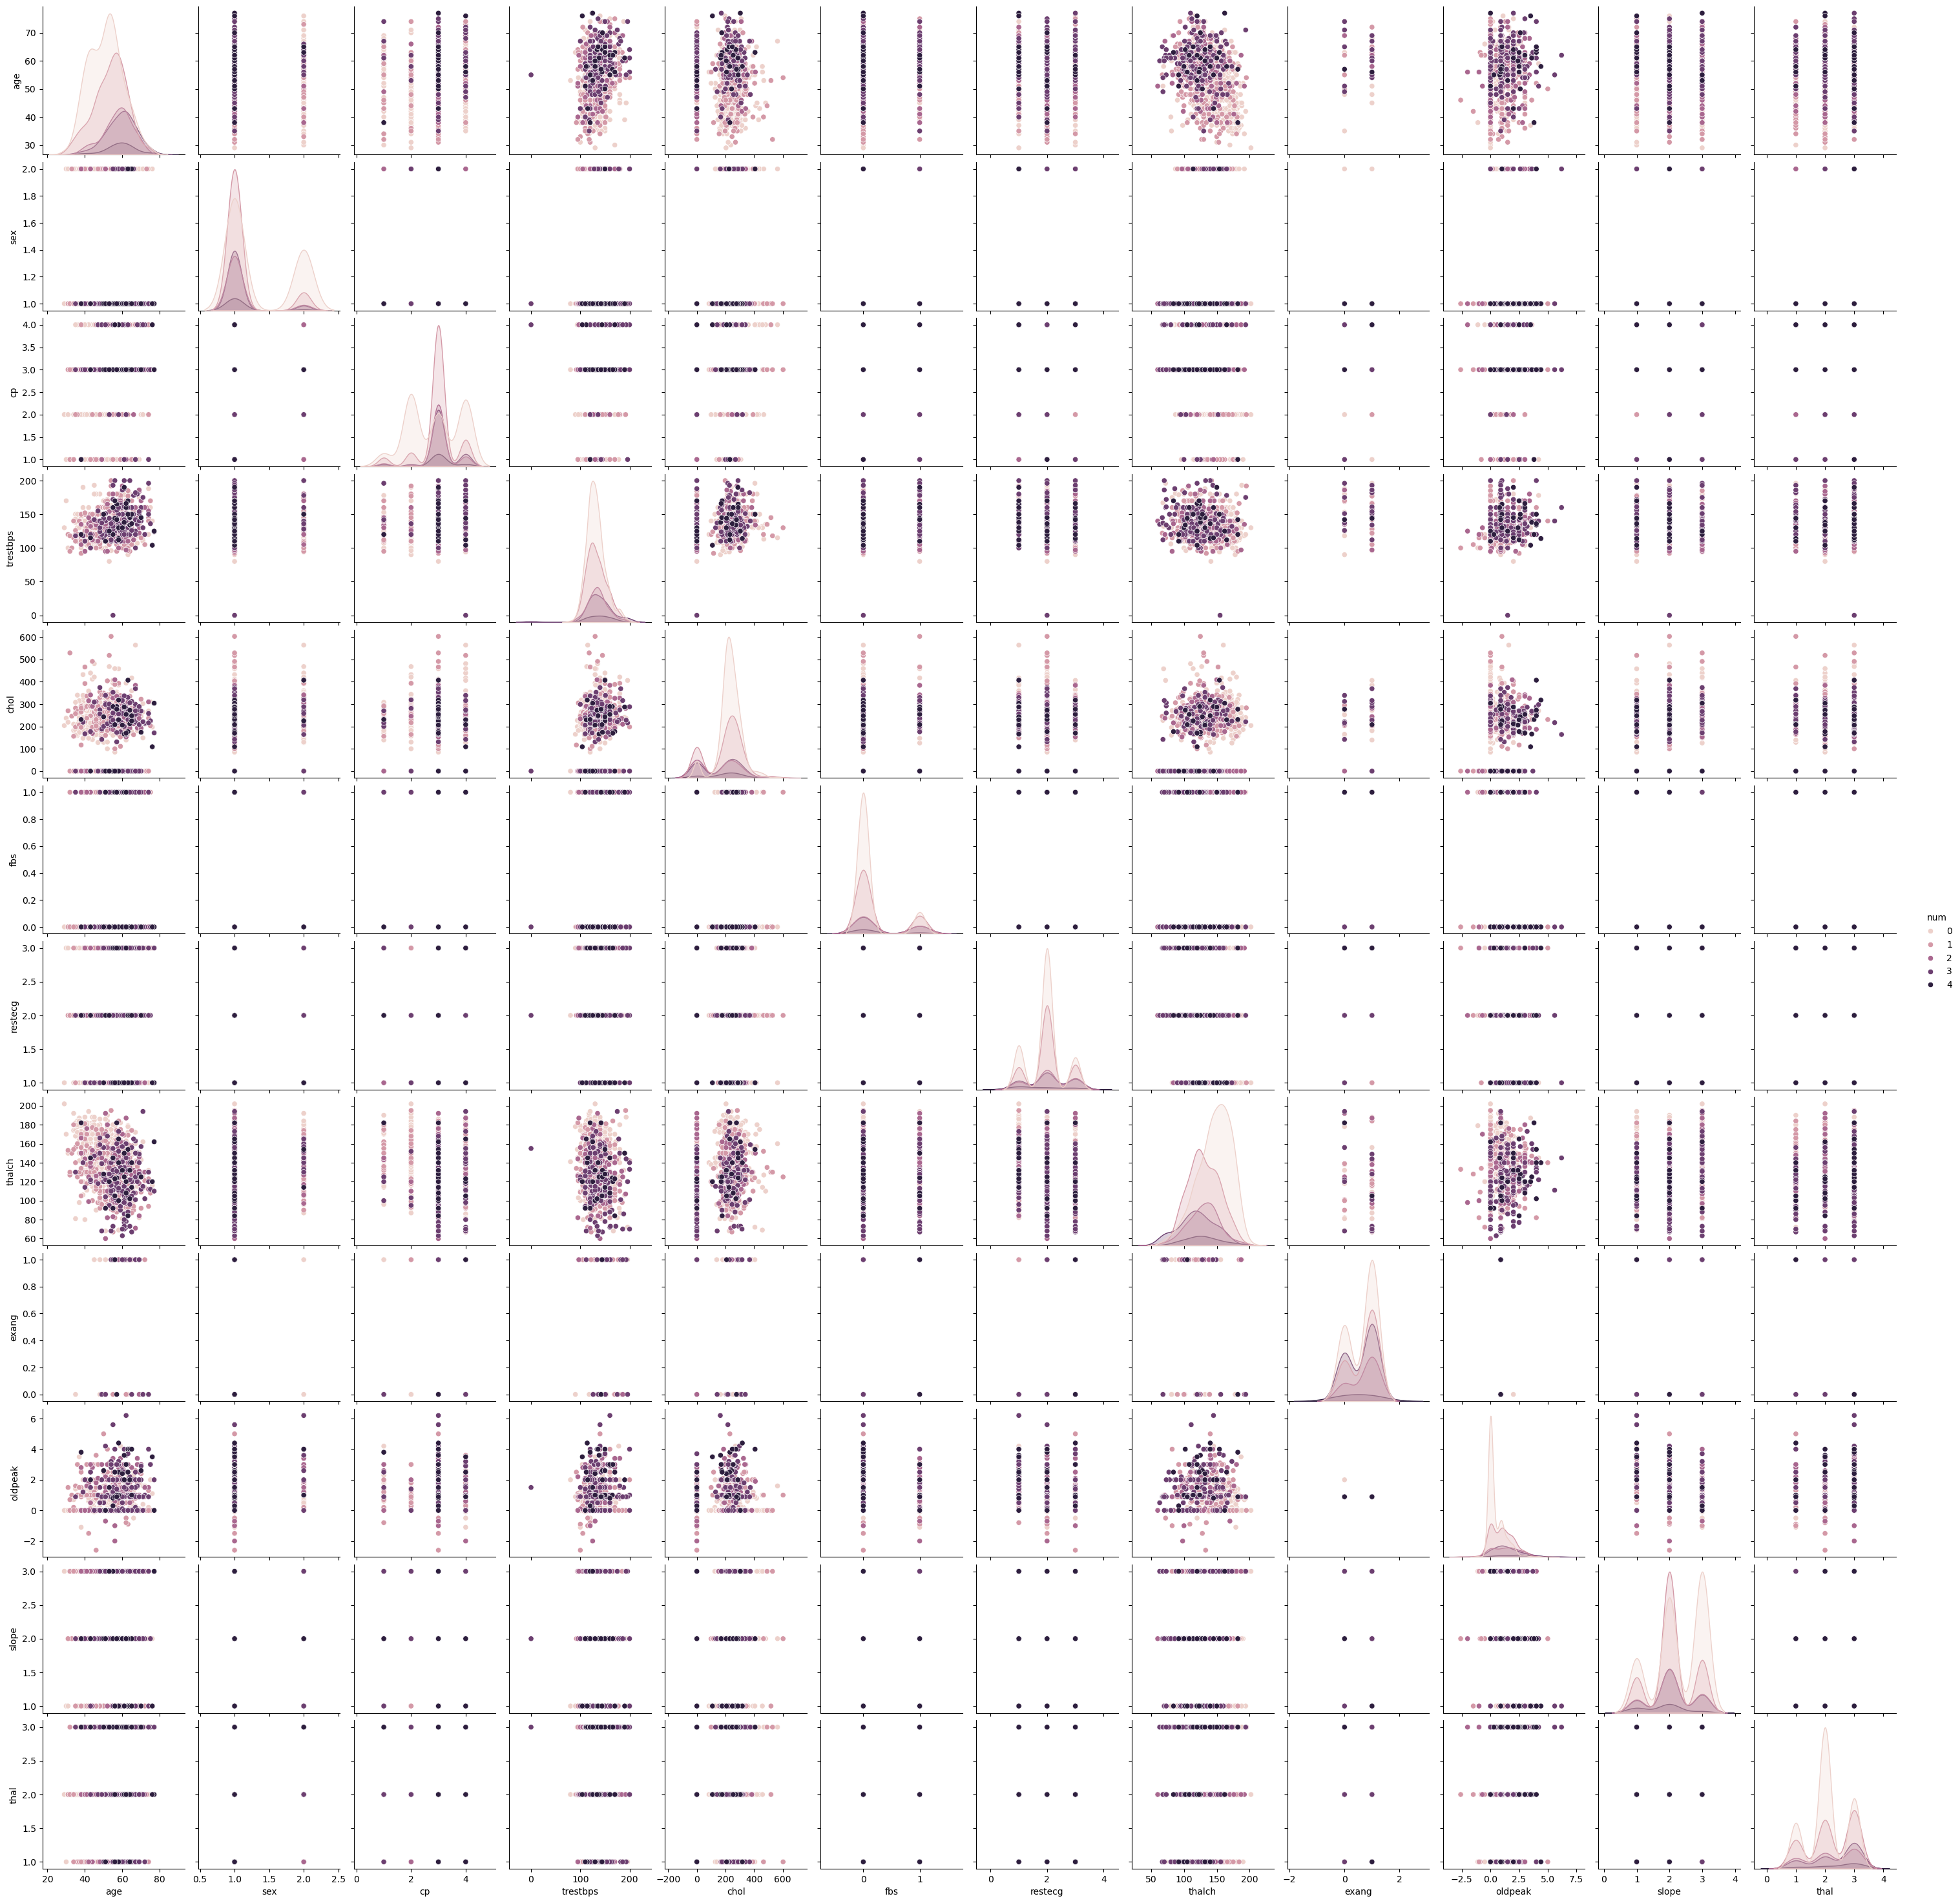

In [54]:
sns.pairplot(data=dataset,hue='num')
plt.show()

In [55]:
dataset_wo = dataset.select_dtypes(exclude=['object']) ## String column can not be used in making heat map

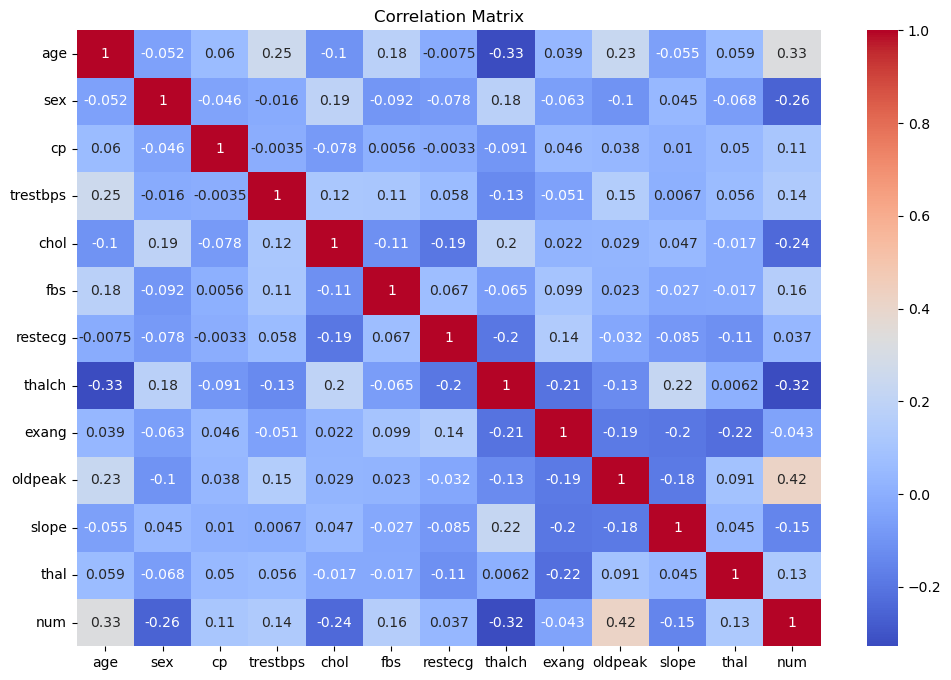

In [56]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset_wo.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

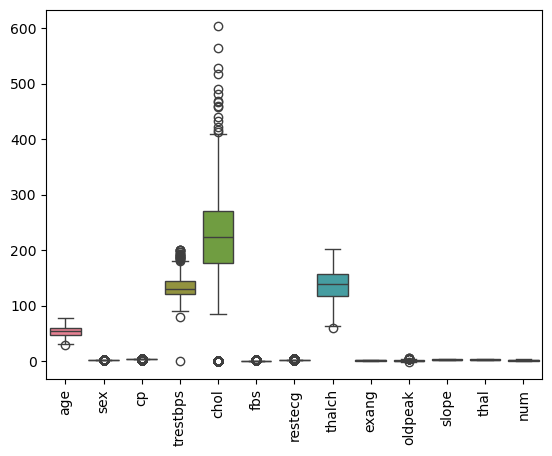

In [57]:
sns.boxplot(data=dataset) 
plt.xticks(rotation=90)
plt.show()

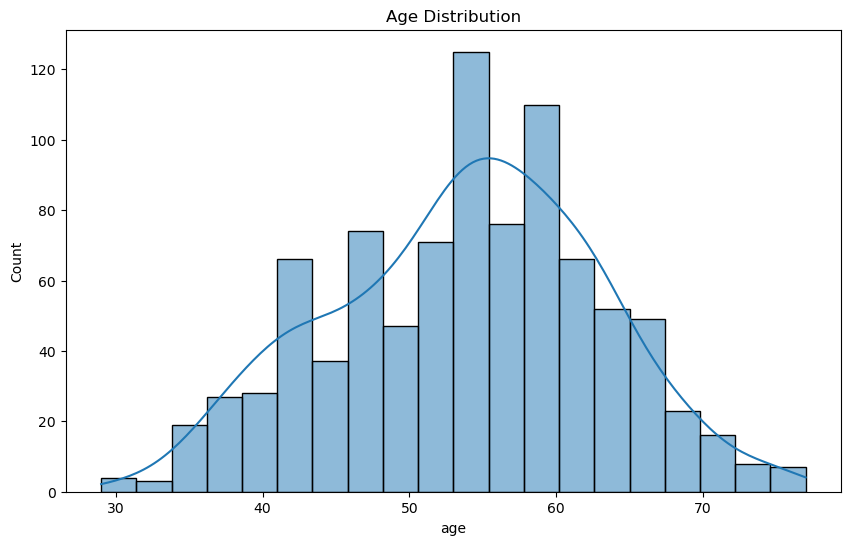

In [58]:
# Plot distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(dataset['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

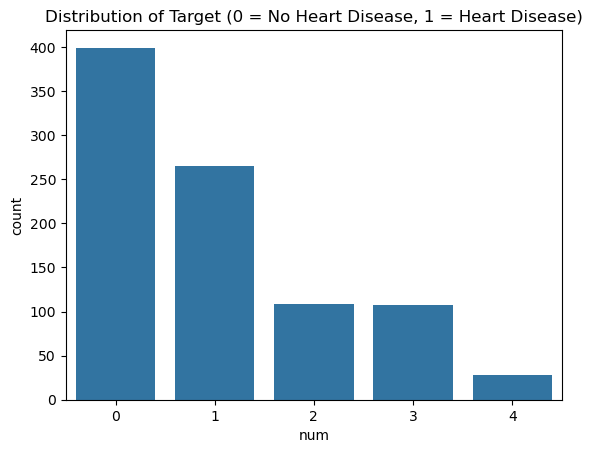

In [59]:
# Plot Target variable distribution
sns.countplot(x='num', data=dataset)
plt.title('Distribution of Target (0 = No Heart Disease, 1 = Heart Disease)')
plt.show()

# 4. Decision Tree Classification:

In [63]:
dataset.dropna(subset=["oldpeak"], inplace=True)

In [69]:
dataset.isna().sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang       853
oldpeak       0
slope         0
thal          0
num           0
dtype: int64

In [70]:
#Split the dataset into input and output/target columns

# input columns: 
x = dataset.iloc[:, 0:12].values

# output columns:
y = dataset.iloc[:, 12]

In [76]:
dataset.shape

(908, 13)

In [71]:
sc = StandardScaler()
x = sc.fit_transform(x)

In [72]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [73]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [77]:
print("Accuracy score: ", accuracy_score(y_test, dt.predict(x_test)))

Accuracy score:  0.5164835164835165


# Visualization of the decision tree:

<Axes: >

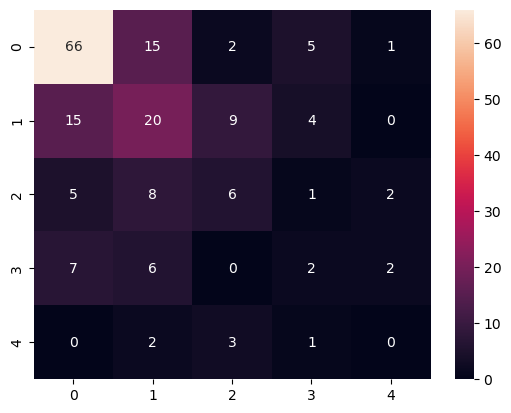

In [78]:
sns.heatmap(confusion_matrix(y_test, dt.predict(x_test)), annot=True)

In [92]:
dataset.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [93]:
cols =['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch','exang', 'oldpeak', 'slope', 'thal', 'num']

[Text(0.3841315881529851, 0.9705882352941176, 'cp <= -0.571\ngini = 0.698\nsamples = 726\nvalue = [310.0, 217.0, 87.0, 90.0, 22.0]'),
 Text(0.0804570895522388, 0.9117647058823529, 'age <= 0.296\ngini = 0.371\nsamples = 161\nvalue = [125.0, 25.0, 5.0, 5.0, 1.0]'),
 Text(0.03731343283582089, 0.8529411764705882, 'oldpeak <= 1.525\ngini = 0.21\nsamples = 112\nvalue = [99, 10, 1, 1, 1]'),
 Text(0.026119402985074626, 0.7941176470588235, 'cp <= -1.862\ngini = 0.168\nsamples = 109\nvalue = [99, 9, 0, 1, 0]'),
 Text(0.014925373134328358, 0.7352941176470589, 'chol <= 0.491\ngini = 0.459\nsamples = 14\nvalue = [9, 5, 0, 0, 0]'),
 Text(0.007462686567164179, 0.6764705882352942, 'chol <= -0.339\ngini = 0.198\nsamples = 9\nvalue = [8, 1, 0, 0, 0]'),
 Text(0.0037313432835820895, 0.6176470588235294, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0, 0, 0]'),
 Text(0.011194029850746268, 0.6176470588235294, 'gini = 0.0\nsamples = 8\nvalue = [8, 0, 0, 0, 0]'),
 Text(0.022388059701492536, 0.6764705882352942, 'tha

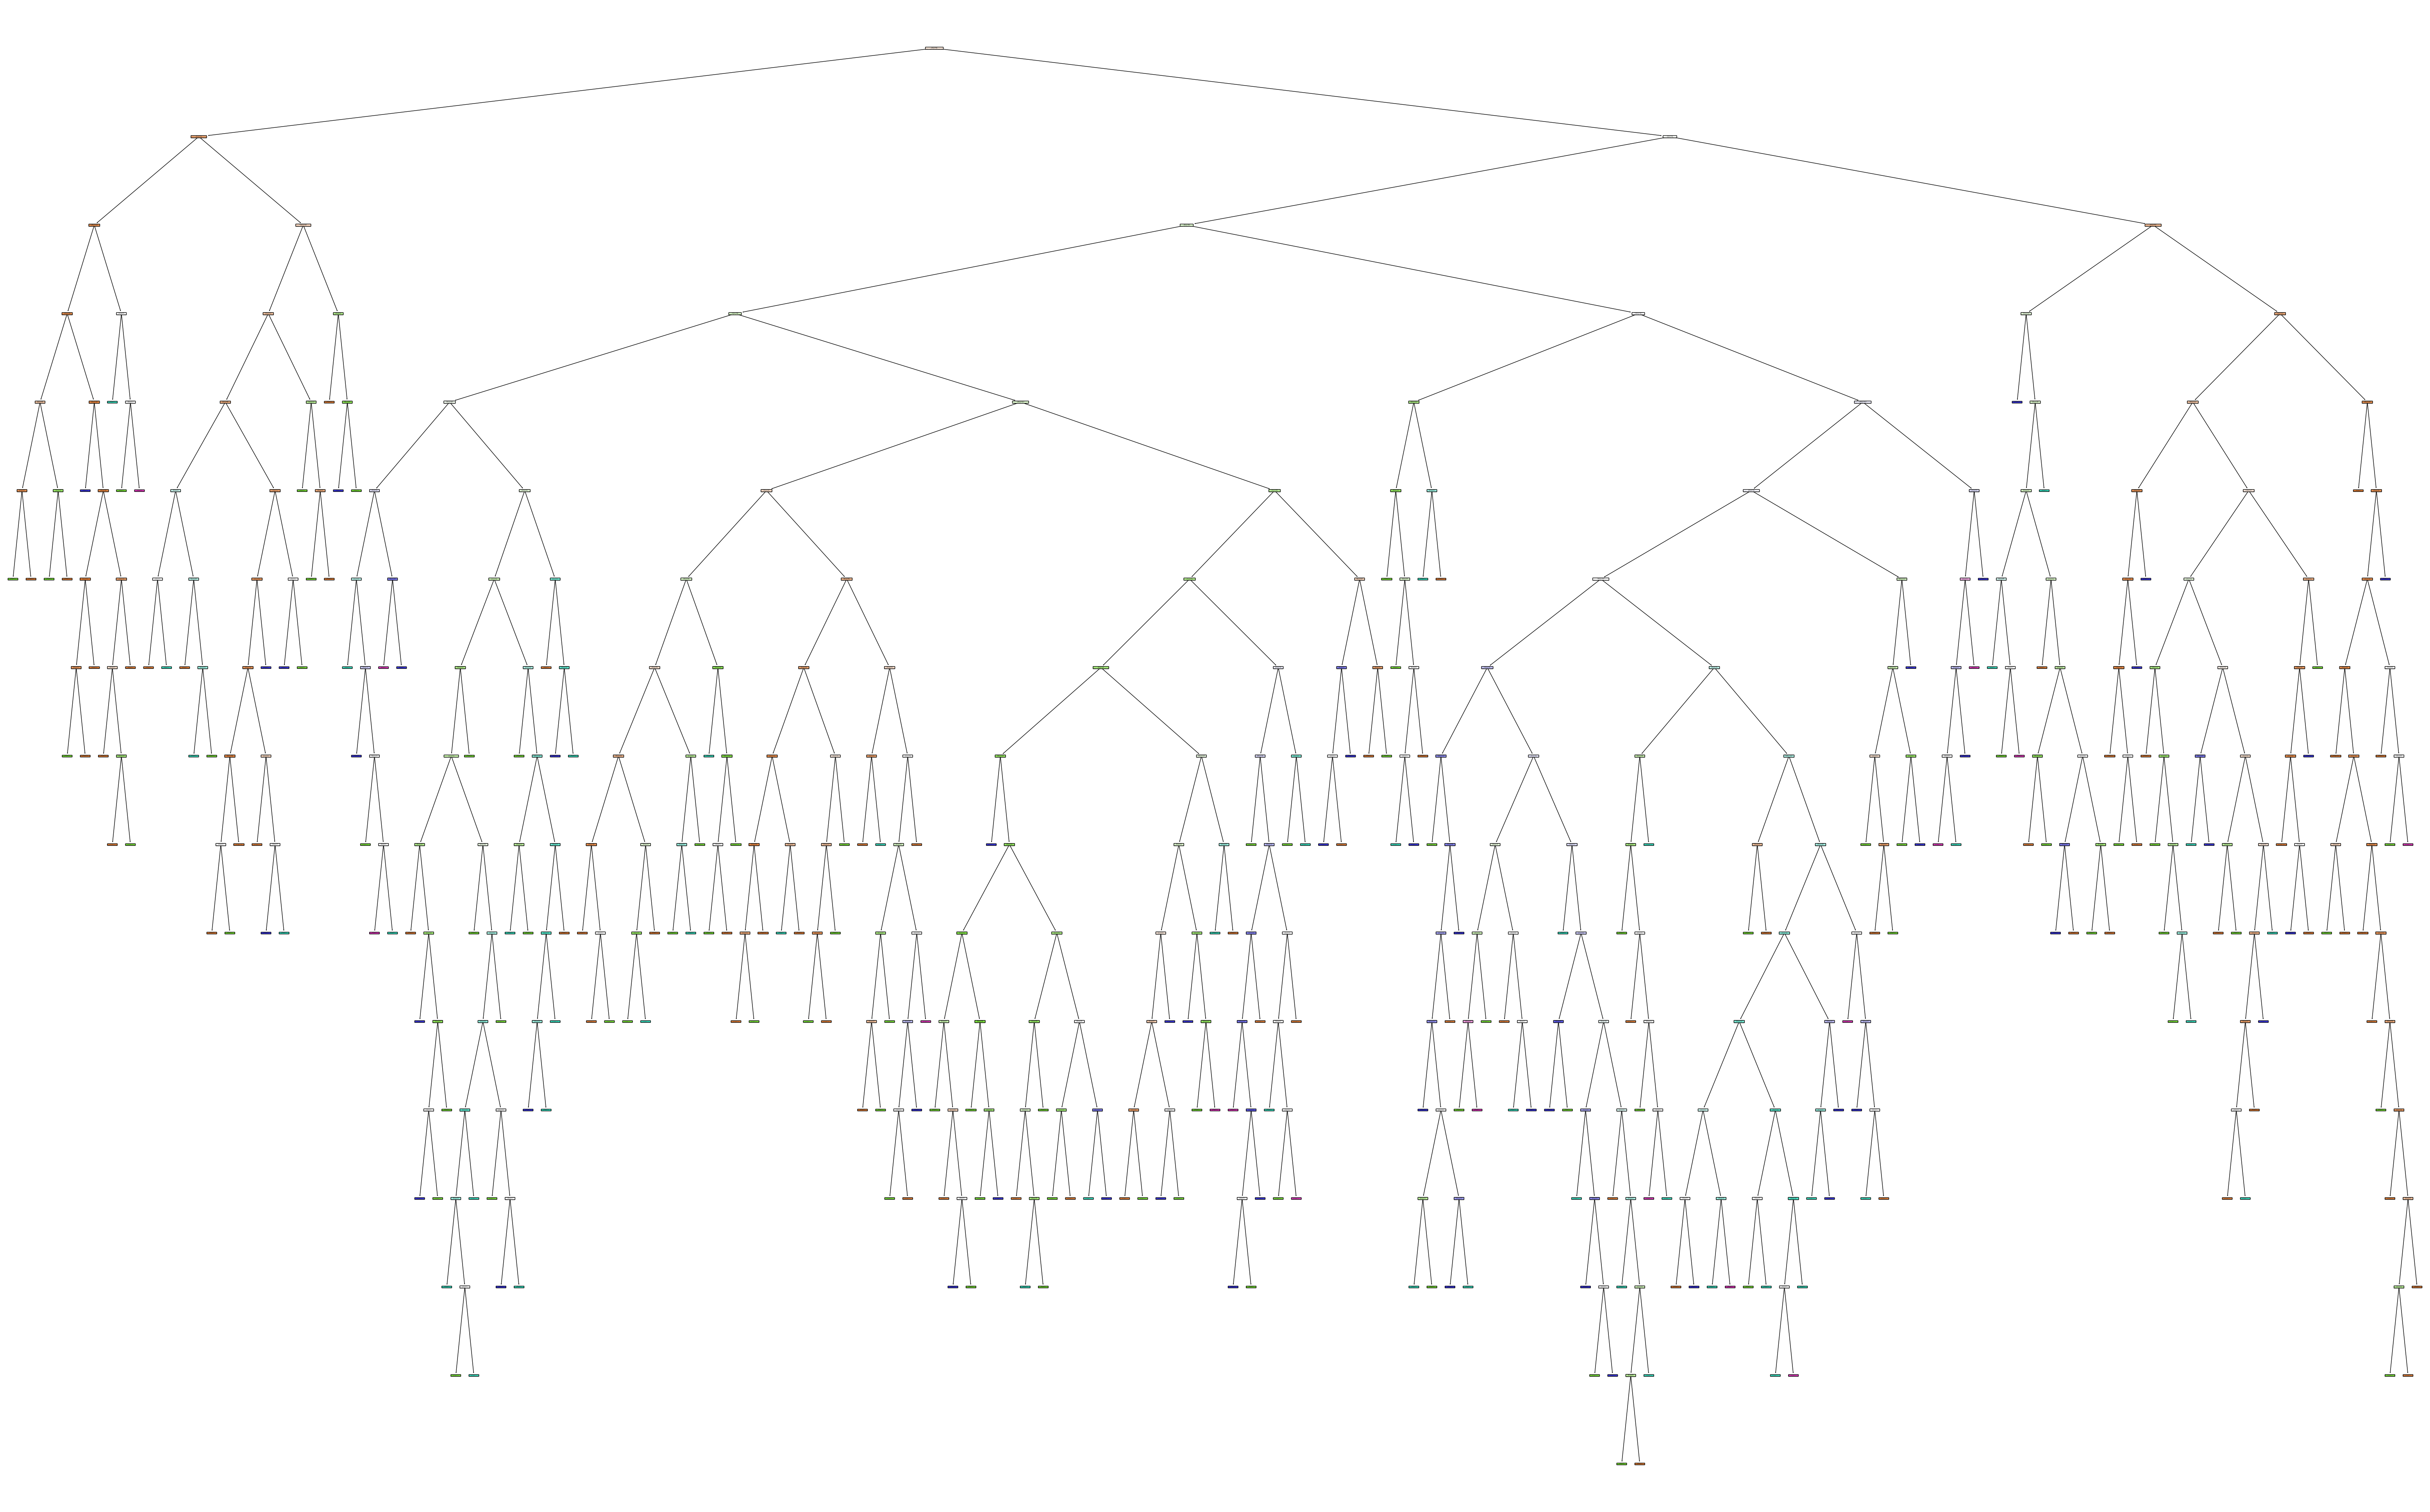

In [94]:
rcParams['figure.figsize'] = 80,50
plot_tree(dt, feature_names=cols, rounded=True, filled=True)

# Interview Questions: